<img src="https://www.unad.edu.co/images/footer/logo-unad-acreditacion-min.png" width="780" height="140" align="right"/>

<p style="text-align: center;"> Course: Advanced Machine Learning</p>

<p style="text-align: center;"> Course code: 203238427 </p>

<p style="text-align: center;"> Group: 01 </p>

<p style="text-align: center;"> Phase 4 - Time series</p>

<p style="text-align: center;">  Presented by: Jeronimo Ramos Ruiz</p>

<p style="text-align: center;">  Tutor: Rafael Gaitán Ospina </p>

<p style="text-align: center;"> UNIVERSIDAD NACIONAL ABIERTA Y A DISTANCIA - UNAD </p>

<p style="text-align: center;"> Medellin, May 2026 </p>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Load dataset

For the development of this work, the data set containing the monthly milk production per cow from January 1962 to December 1975 was selected. It is assumed that the unit of measurement corresponds to the liters measured after one day of production.

In [2]:
# We load the data from the GitHub repository to avoid problems
# with importing it if working with a Colab kernel

path = 'https://raw.githubusercontent.com/Jero2110/Advanced-ML_Phase-04/refs/heads/main/analysis/data/monthly-milk-production-pounds-p(in).csv'


df = pd.read_csv(path, parse_dates=['Month'], index_col='Month')
df = df.rename(columns={'Monthly milk production: pounds per cow. Jan 62 ? Dec 75': 'Milk_production'})

df.tail()


,Milk_production
Month,
1975-10,827.0
1975-11,797.0
1975-12,843.0
NaN,NaN
Monthly milk production: pounds per cow. Jan 62 ? Dec 75,NaN


In many cases, when importing data from a CSV file, some records in the last few rows may not be relevant for analysis. Therefore, they will be removed from the working data frame.

In [3]:
df_clean = df.dropna()

df_clean.index = pd.to_datetime(df_clean.index)

df_clean.tail()

,Milk_production
Month,
1975-08-01,858.0
1975-09-01,817.0
1975-10-01,827.0
1975-11-01,797.0
1975-12-01,843.0


Once these rows have been removed, we will proceed to identify possible missing data and outliers with the help of the boxplot:

In [4]:
# First we will identify the null values

rows = df_clean.shape[0]
null_rows = df_clean.isna().sum()

print('---'*30)
print(f'The data set has {rows} rows, of which {null_rows} have null values')
print('---'*30)

------------------------------------------------------------------------------------------
The data set has 168 rows, of which Milk_production    0
dtype: int64 have null values
------------------------------------------------------------------------------------------


In [5]:
df_clean['Milk_production'].describe()

,Milk_production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


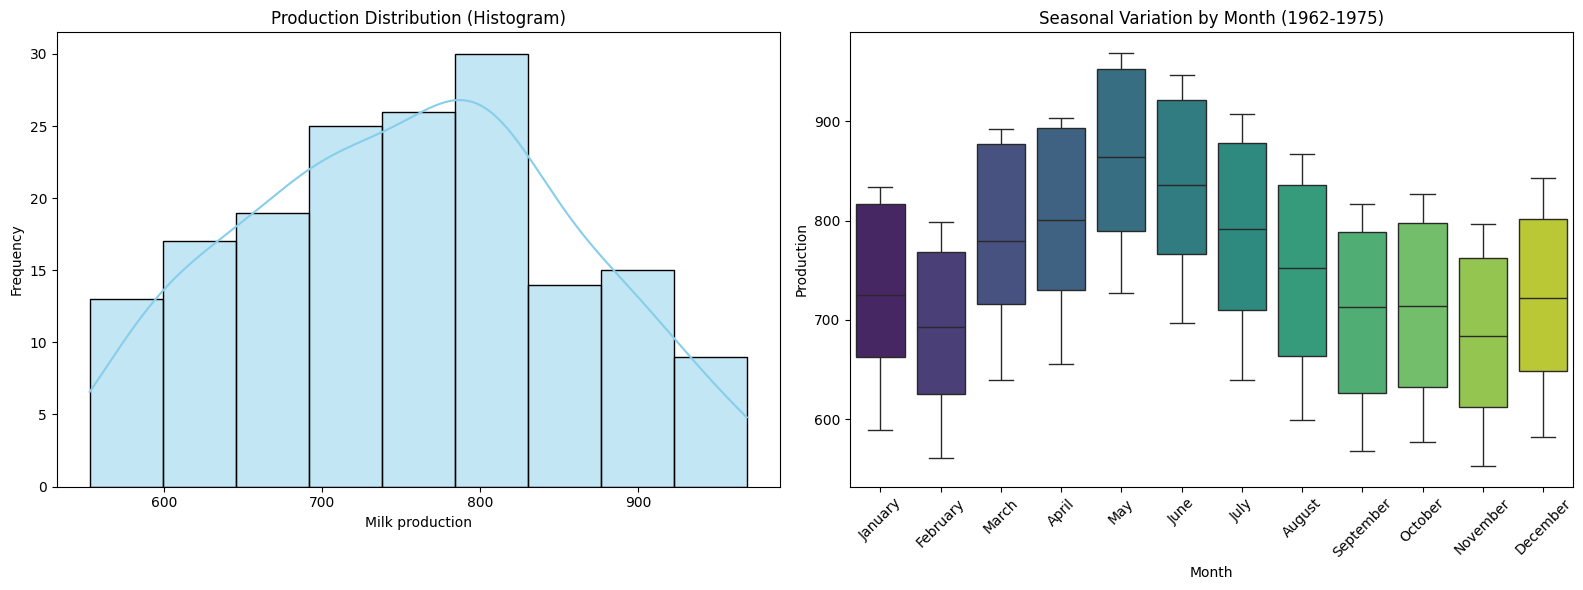

In [6]:
# 1. Data Preparation
df_clean_graphs = df_clean.copy() 
df_clean_graphs['Month_Name'] = df_clean_graphs.index.month_name() # Extract the name of the month
df_clean_graphs['Month_Num'] = df_clean_graphs.index.month         # Extract the number to sort


fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# --- CHART 1: Histogram ---
sns.histplot(df_clean_graphs['Milk_production'], kde=True, ax=ax[0], color='skyblue')
ax[0].set_title('Production Distribution (Histogram)')
ax[0].set_xlabel('Milk production')
ax[0].set_ylabel('Frequency')

# --- CHART 2: Monthly Boxplot ---
# We ordered by month number so that it starts in January
df_sorted = df_clean_graphs.sort_values('Month_Num')
sns.boxplot(x='Month_Name', y='Milk_production', data=df_sorted,
            ax=ax[1], palette='viridis', hue='Month_Name', legend=False)
ax[1].set_title('Seasonal Variation by Month (1962-1975)')
ax[1].set_xlabel('Month')
ax[1].set_ylabel('Production')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

As can be seen in the box plot, there appear to be no outliers in the selected dataset, as all values ​​fall within the interquartile range. However, some seasonality is observed throughout the year, with peak production between April and June and lower production between December and February.

It is also observed that the data tend to cluster around 700 and 800 milk production units, which is very close to the overall mean of the dataset, which is 754.7 units.

Therefore, we can proceed with the analysis with the certainty that there are no outliers.

However, since the data covers all 12 months of each year, the records will be counted by year to identify any missing values ​​that need to be corrected.

In [7]:
records_per_year = df_clean.index.year.value_counts().sort_index()

print('---'*30)
print(f'{records_per_year}')
print('---'*30)

------------------------------------------------------------------------------------------
Month
1962    12
1963    12
1964    12
1965    12
1966    12
1967    12
1968    12
1969    12
1970    12
1971    12
1972    12
1973    12
1974    12
1975    12
Name: count, dtype: int64
------------------------------------------------------------------------------------------


As can be seen in the table above, there does not appear to be any missing data, as all years of study seem to contain information for each of the months of study.

# Step 1

Now that we know the information is clean, we will proceed to identify, using a line graph, the possible presence of trend and seasonality.

/tmp/ipykernel_3887/2013624275.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.loc[:, 'Year'] = df_clean.index.year
/tmp/ipykernel_3887/2013624275.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.loc[:,'Month'] = df_clean.index.month


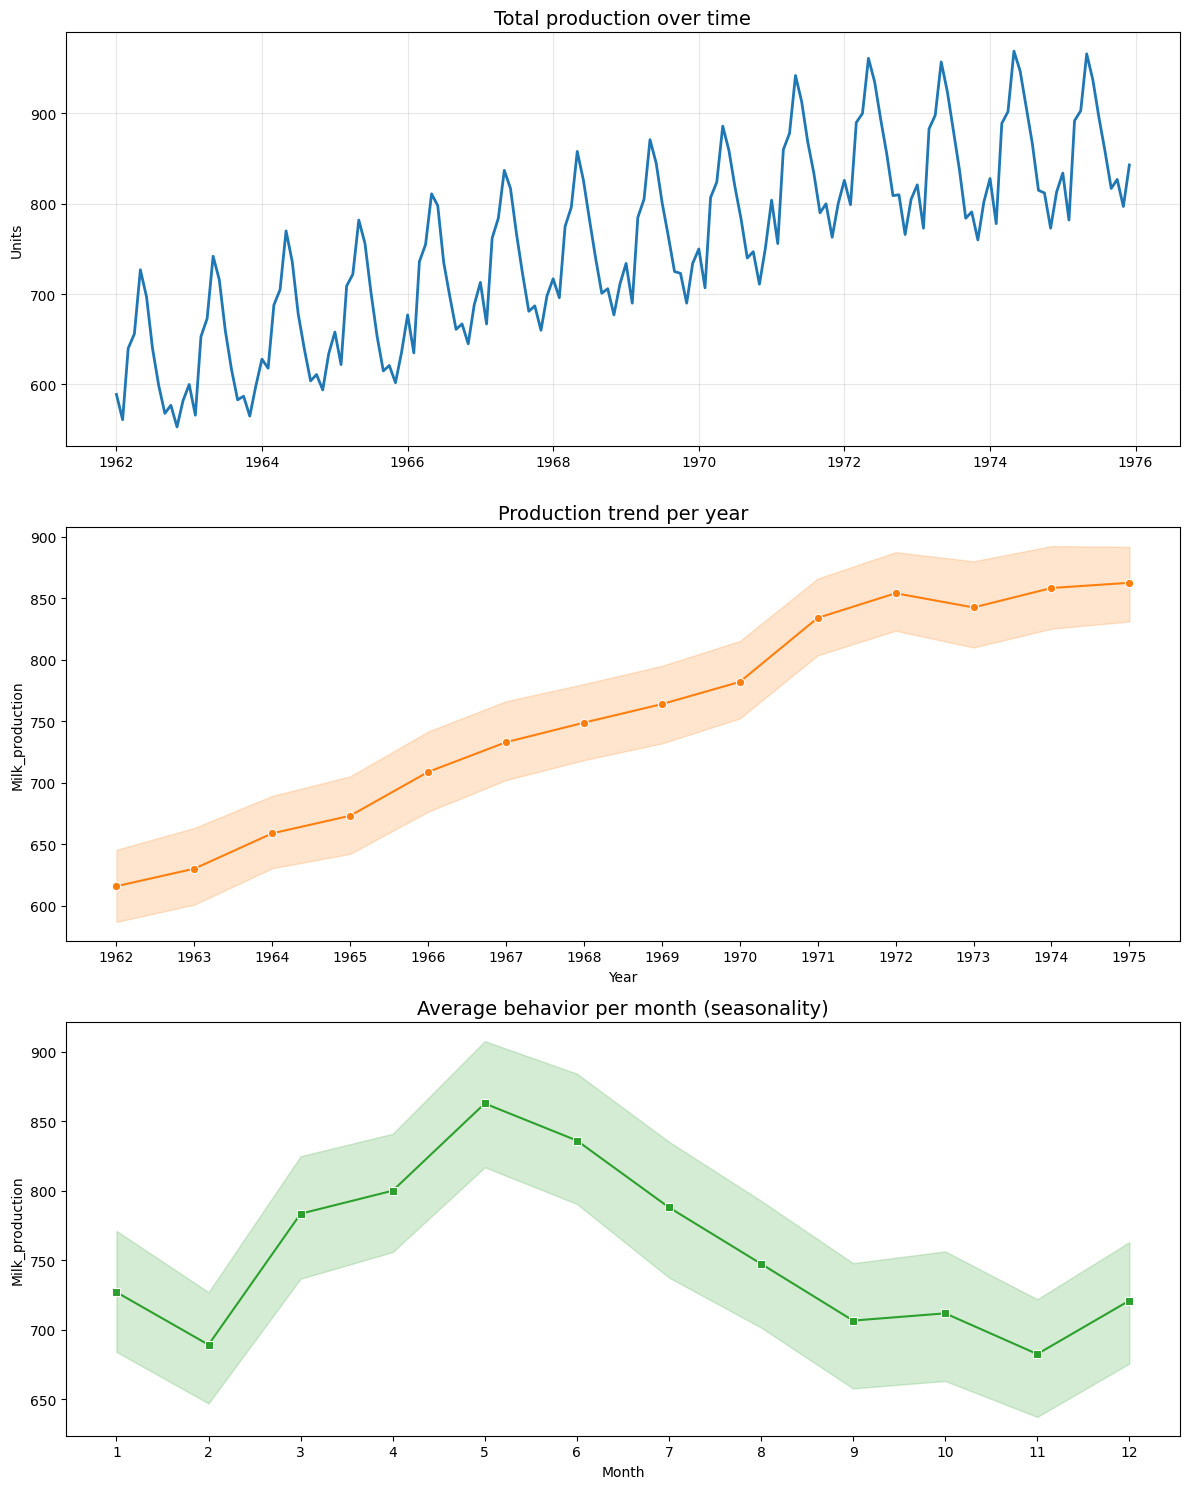

In [8]:
# First wwe create the columns with the information of the day, month and year 
# Crear las nuevas columnas
df_clean.loc[:, 'Year'] = df_clean.index.year
df_clean.loc[:,'Month'] = df_clean.index.month

# Line graph (to visualize monthly production over time in different times)
fig, axes = plt.subplots(3, 1, figsize=(12, 15))

# Chart 1: Complete time series (solid line)
axes[0].plot(df_clean.index, df_clean['Milk_production'], color='tab:blue', linewidth=2)
axes[0].set_title('Total production over time', fontsize=14)
axes[0].set_ylabel('Units')
axes[0].grid(True, alpha=0.3)

# Chart 2: Variation by Year (Using the 'Year' column)
sns.lineplot(data=df_clean, x='Year', y='Milk_production', ax=axes[1], color='tab:orange', marker='o')
axes[1].set_title('Production trend per year', fontsize=14)
axes[1].set_xticks(df_clean['Year'].unique())

# Chart 3: Seasonality by month (using the 'Month' column)
sns.lineplot(data=df_clean, x='Month', y='Milk_production', ax=axes[2], color='tab:green', marker='s')
axes[2].set_title('Average behavior per month (seasonality)', fontsize=14)
axes[2].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()


In the graphs above we can observe the normal behavior of the data series (first graph with blue lines), the possible trend of the data over the years (second graph with orange lines) and the possible presence of temporality through the months of study (last graph in green).

The first graph shows a clear upward trend in the data, which is confirmed in the second. This indicates that monthly milk production is increasing over time, either due to an increase in the number of cattle or improvements in milk extraction and feeding technologies. On the other hand, a recurring pattern is observed in the middle of the year, as confirmed by the third graph.

It appears that milk production peaks in May and then declines throughout the year. This could be related to the seasons in some countries, where cold weather influences food production and vegetation, as well as the ability of cows to produce milk, since they use all their energy to survive the cold. Meanwhile, between April and July, the weather is suitable for food production and there is not as much stress to affect the animals' milk production.

# Step 2

Now that we understand the behavior of the time series, we can see that there are some properties that can be difficult to analyze when using a forecasting method such as ARIMA or LSTM.

To apply a predictive model like ARIMA, the series must be stationary, meaning its statistical properties do not change over time. This allows the model to focus on understanding the internal structure of the data rather than on predictable and repetitive variables (trends and cycles), resulting in a more reliable model.

With this in mind, we aim for the mean and variance to be constant. On one hand, the mean indicates the trend that may exist in the data, meaning it changes depending on the observation point, making it difficult for the model to predict the future if the baseline is constantly changing. On the other hand, the variance indicates seasonality or patterns that repeat at regular intervals. These patterns make the variance behave in a predictable, but somewhat unstable, way.

In [9]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

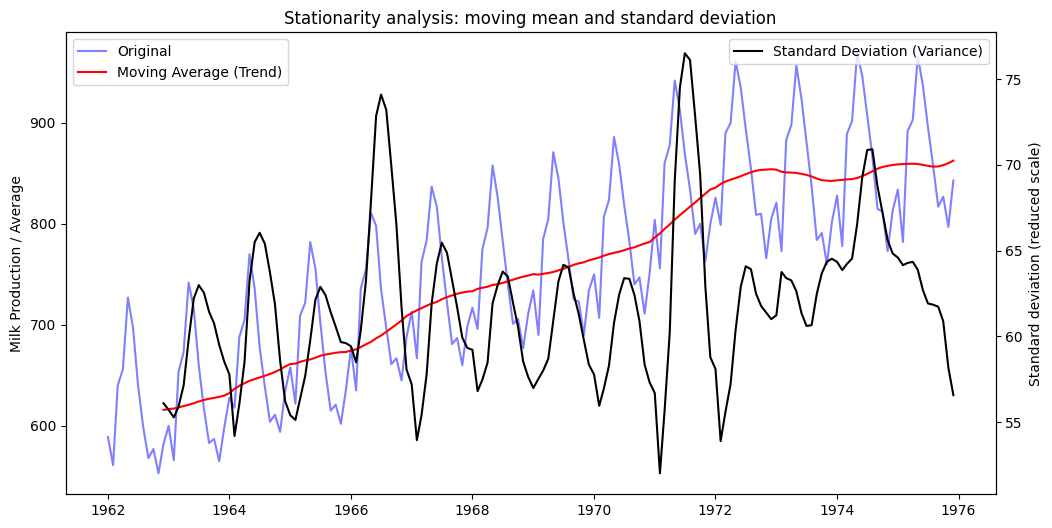

In [10]:
# We want to check if the time series is stationary, which means that all its statistical properties are constant over time.
rolmean = df_clean['Milk_production'].rolling(window=12).mean()
rolstd = df_clean['Milk_production'].rolling(window=12).std()

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(df_clean['Milk_production'], color='blue', label='Original', alpha=0.5)
ax1.plot(rolmean, color='red', label='Moving Average (Trend)')
ax1.set_ylabel('Milk Production / Average')
ax1.legend(loc='upper left')

# We create the second axis that shares the same X-axis.
ax2 = ax1.twinx()
plt.plot(rolstd, color='black', label='Standard Deviation (Variance)')
ax2.set_ylabel('Standard deviation (reduced scale)')
plt.legend(loc='upper right')


plt.title('Stationarity analysis: moving mean and standard deviation')
plt.show()

In the graph above, the blue line represents the initial time series with a clear trend and marked seasonality, occurring approximately every 12 months. This trend is confirmed by the increasing behavior of the mean, represented by the red line, and the variance shows production peaks close to the identified time. However, production peaks are also observed around the years 1966, 1971, and 1972. These records could indicate special conditions in milk production, such as extreme weather, difficulties in feeding the animals, or, conversely, good production due to ideal conditions.

<Figure size 1200x400 with 0 Axes>

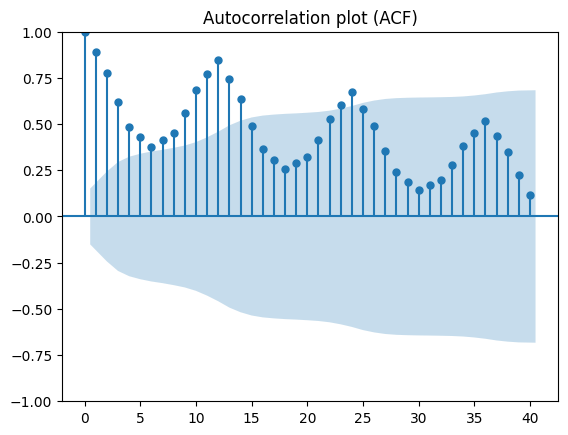

In [11]:
plt.figure(figsize=(12, 4))
plot_acf(df_clean['Milk_production'], lags=40)
plt.title('Autocorrelation plot (ACF)')
plt.show()

Using the Autocorrelation Factor (ACF) chart, we can observe that the bars remain high and outside the blue shaded area (the confidence interval) for many lags. This confirms that past values ​​have a strong influence on current values, indicating a trend.

On the other hand, the "wave" or peak pattern is clearly repeating. There is a very defined peak near lag 12 and another at lag 24. This indicates a 12-month seasonal cycle. In other words, this suggests that what happened in January of last year is an excellent predictor of what will happen in January of this year.

In [12]:
print('Resultados de la prueba de Dickey-Fuller:')
dftest = adfuller(df_clean['Milk_production'], autolag='AIC')

dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
for key, value in dftest[4].items():
    dfoutput[f'Critical Value ({key})'] = value

print(dfoutput)


Resultados de la prueba de Dickey-Fuller:
Test Statistic                  -1.303812
p-value                          0.627427
#Lags Used                      13.000000
Number of Observations Used    154.000000
Critical Value (1%)             -3.473543
Critical Value (5%)             -2.880498
Critical Value (10%)            -2.576878
dtype: float64


Finally, using the Dickey-Fuller test, which aims to determine if the data are stationary (constant mean and variance), we can observe, by analyzing the p-value > 0.5, that the null hypothesis cannot be rejected.

Therefore, based on all the evidence presented above, it is possible to conclude that the series is NOT stationary. With this in mind, it is necessary to apply a differentiation.

## Differentiation

The differentiation consists of subtracting the previous value from the current value to eliminate the trend, as well as subtracting the value from the same month of the previous year to eliminate seasonality.

Since seasonality was identified in previous steps, it is necessary to apply ordinary differentiating, where the current month is subtracted from the previous month to eliminate the trend. Subsequently, the current month is subtracted from the same month of the previous year to eliminate seasonality.

In [13]:
# 1. Simple difference (eliminates the trend)
df_clean['diff_1'] = df_clean['Milk_production'].diff()

# 2. Seasonal difference over the simple one (eliminates seasonality)
df_clean['diff_12'] = df_clean['diff_1'].diff(12)

# Remove NaN values ​​generated by differentiation
df_stationary = df_clean.dropna()


/tmp/ipykernel_3887/3485871358.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['diff_1'] = df_clean['Milk_production'].diff()
/tmp/ipykernel_3887/3485871358.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['diff_12'] = df_clean['diff_1'].diff(12)


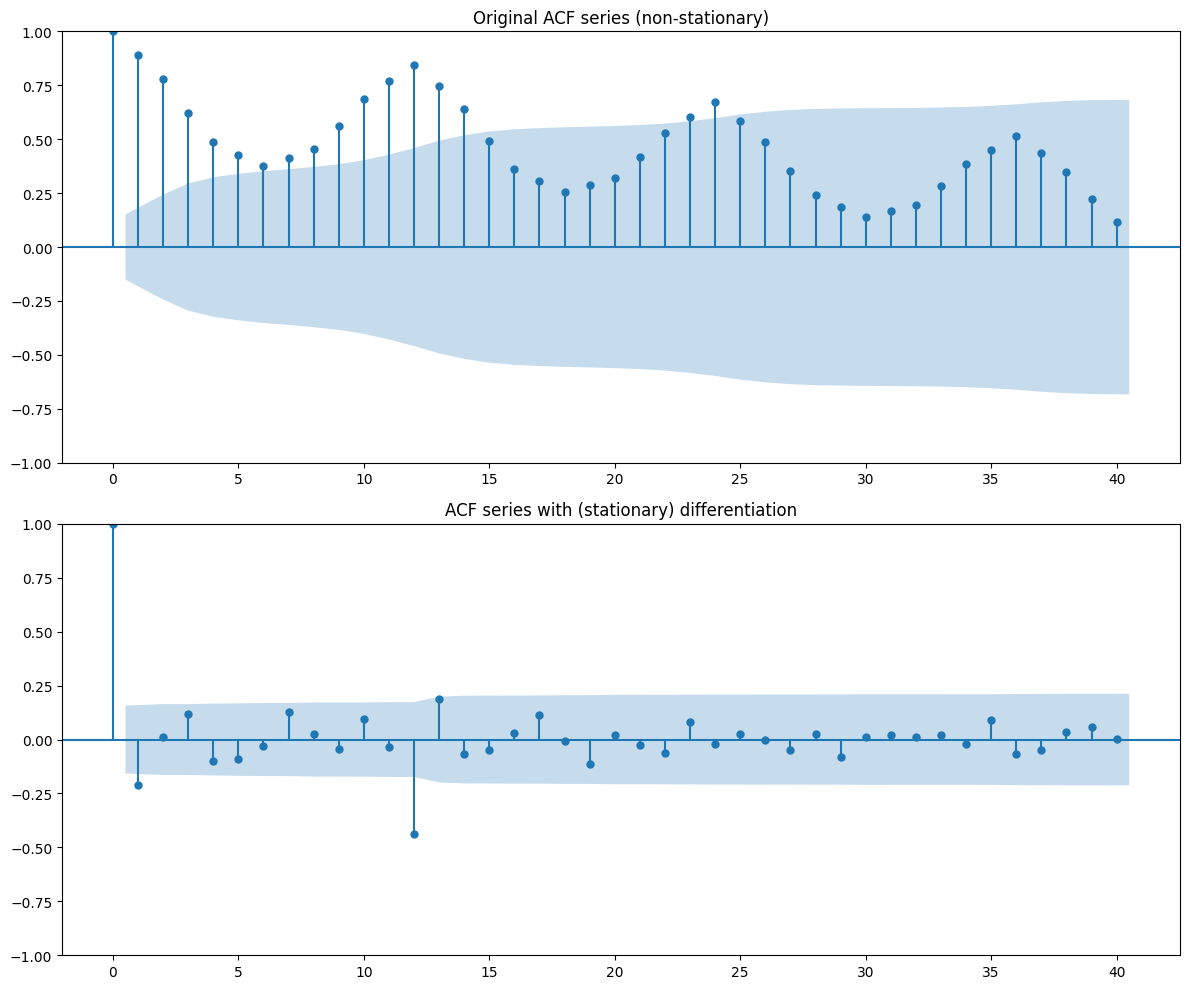

In [14]:
# Visualization and comparison

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# ACF from the original series
plot_acf(df_clean['Milk_production'], ax=axes[0], lags=40)
axes[0].set_title('Original ACF series (non-stationary)')

# ACF series with double differentiation
plot_acf(df_stationary['diff_12'], ax=axes[1], lags=40)
axes[1].set_title('ACF series with (stationary) differentiation')

plt.tight_layout()
plt.show()


In [15]:
resultado = adfuller(df_stationary['diff_12'])
print(f'p-value after differentiating: {resultado[1]}')

if resultado[1] <= 0.05:
    print("Success! The series is now stationary.")
else:
    print("The series is not yet stationary; it may require another transformation.")


p-value after differentiating: 1.865423431878848e-05
Success! The series is now stationary.


As can be seen, by twice differentiating the selected time series, it is possible to eliminate seasonality and trends in the data. This can be verified with the results of the Dickey-Fuller test and the autocorrelation function (ACF) plot, where the results tend to fall within the defined confidence interval in a shorter time frame, without exhibiting constant peaks or cyclical behavior.

## Data Splitting

Since the order in which data is selected influences the results obtained in time series analysis, the data cannot be divided randomly. Therefore, it is necessary to collect the data sequentially, separating them according to the selected proportion, so that the models are trained with the oldest data and tested with the most recent.

In [16]:
# Calculate the cut-off point (70%)
train_size = int(len(df_stationary) * 0.7)

# Divide the series (it is important to maintain the chronological order).
train = df_stationary.iloc[:train_size]
test = df_stationary.iloc[train_size:]

print(f"Total records: {len(df_stationary)}")
print(f"Training records: {len(train)}")
print(f"Test records: {len(test)}")


Total records: 155
Training records: 108
Test records: 47


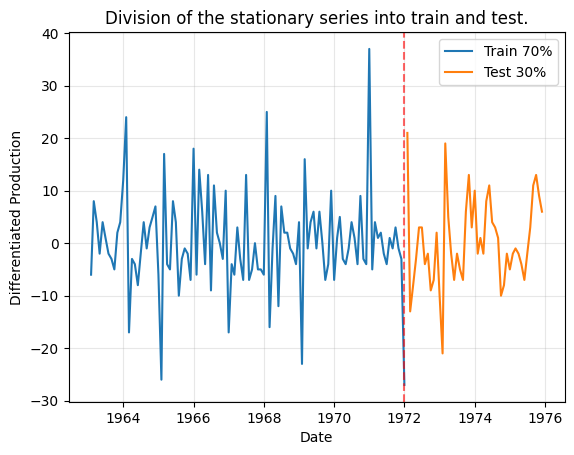

In [17]:
# Graph training data
plt.plot(train.index, train['diff_12'], label='Train 70%', color='tab:blue')

# Graphic test data
plt.plot(test.index, test['diff_12'], label='Test 30%', color='tab:orange')

# Add a vertical line to mark the division.
plt.axvline(train.index[-1], color='red', linestyle='--', alpha=0.6)

plt.title('Division of the stationary series into train and test.')
plt.xlabel('Date')
plt.ylabel('Differentiated Production')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In the graph above, we can see that the data no longer behaves the same way as before. This is due to the differentiation we performed, where we specifically removed the trend and seasonality that characterized the selected dataset. However, we can see that the ordinality of the data was not altered, which will allow us to train the model with the historical data and test it with the recent data.

# Step 3 - ARIMA Model

The ARIMA (Autoregressive Integrated Moving Average) model is a statistical technique used to analyze and forecast time series data, based on past values, trends, and forecast errors. It combines three components (p, d, q) to model non-seasonal patterns, requiring the series to be stationary.

**ARIMA Components *(p, d, q)***

- *AR (p)*: Autoregressive. Uses the dependent relationship between a current observation and a given number of past observations (lags).
- *I (d)*: Integrated. Applies differencing (subtracting current values ​​from previous ones) to make the time series stationary.
- *MA (q)*: Moving Average. Uses the dependency between an observation and the residual error of a moving average model applied to past observations.

In [18]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from itertools import product

Since the ARIMA model includes a hyperparameter for data differencing, the initial dataset will be used so that the model itself can perform this differencing. To find the best parameters that match the already calculated value of *d*, *d* will be initialized to 1 to prevent the model from getting stuck in an indeterminate error and failing to find the desired optimal solution.

In [ ]:
# Calculate the cut-off point (70%)
train_size = int(len(df_clean) * 0.7)

# Divide the series (it is important to maintain the chronological order).
train_data = df_clean.iloc[:train_size]
test_data = df_clean.iloc[train_size:]

print(f"Total records: {len(df_clean)}")
print(f"Training records: {len(train_data)}")
print(f"Test records: {len(test_data)}")

# Define ranges for p, d, q
train_data.index.freq = 'MS' 
p = q = range(0, 3)
d = range(1, 3) 
pdq_combinations = list(product(p, d, q))

best_aic = float("inf")
best_order = None

# Find the best combination in the training set
for order in pdq_combinations:
    try:
        model = ARIMA(train_data['Milk_production'], order=order,
                      enforce_stationarity=False, 
                      enforce_invertibility=False).fit()
        if model.aic < best_aic:
            best_aic = model.aic
            best_order = order
    except:
        continue

print(f"Mejor ARIMA {best_order} - AIC: {best_aic}")


Total records: 168
Training records: 117
Test records: 51
Mejor ARIMA (2, 2, 2) - AIC: 1153.5379497163392


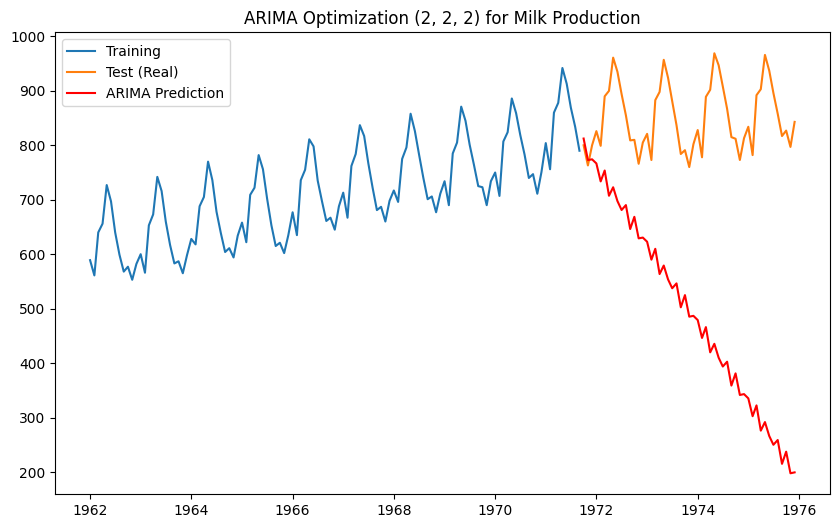

In [ ]:
# Adjust model with the best order
model_final = ARIMA(train_data['Milk_production'], order=best_order).fit()

# Generate a prediction for the size of the test set
forecast = model_final.get_forecast(steps=len(test_data['Milk_production']))
pred_mean = forecast.predicted_mean

# Graph
plt.figure(figsize=(10,6))
plt.plot(train_data['Milk_production'], label='Training')
plt.plot(test_data['Milk_production'], label='Test (Real)')
plt.plot(pred_mean, label='ARIMA Prediction', color='red')
plt.title(f'ARIMA Optimization {best_order} for Milk Production')
plt.legend()
plt.show()


As shown in the graph above, the ARIMA model, even with optimized hyperparameters, fails to accurately predict the time series values ​​in the test set. This may be due to the model's limitations with time series exhibiting strong trends and seasonality. For this reason, the SARIMA (Seasonal Autoregressive Integrated Moving Average) model was chosen, an advanced time series forecasting technique that extends the ARIMA model's ability to handle data with trends and seasonality.

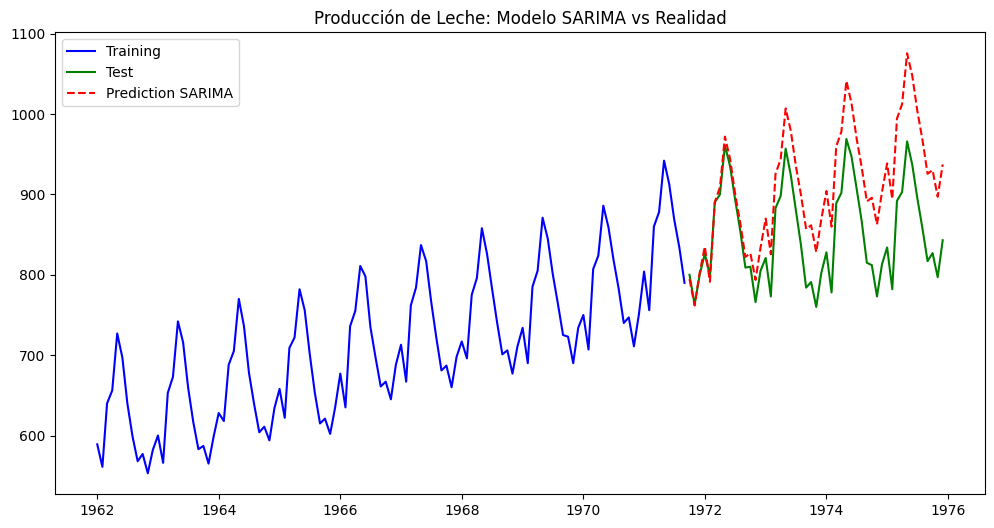

In [ ]:
# We structured the SARIMA model.
model = SARIMAX(train_data['Milk_production'], 
                order=(1, 1, 1), 
                seasonal_order=(1, 1, 1, 12),
                enforce_stationarity=False, 
                enforce_invertibility=False).fit(disp=False)

# We make the prediction
forecast = model.get_forecast(steps=len(test_data['Milk_production']))
pred_mean = forecast.predicted_mean

# Graph
plt.figure(figsize=(12, 6))
plt.plot(train_data['Milk_production'], label='Training', color='blue')
plt.plot(test_data['Milk_production'], label='Test', color='green')
plt.plot(pred_mean, label='Prediction SARIMA', color='red', linestyle='--')
plt.title('Producción de Leche: Modelo SARIMA vs Realidad')
plt.legend()
plt.show()


As can be seen in the graph above, the model is able to adequately follow the seasonality of the data; however, because the data in the test set appear to be decreasing or stagnating, the trend learned by the model is not fulfilled and tends to continue the learned trend, moving further and further away from the real data as time goes on.

# Step 4 - Prophet Model

Prophet is an open-source, additive time-series forecasting model developed by Meta (Facebook), designed for high-quality, automated forecasting of business metrics. It excels with data showing strong seasonal patterns, multiple seasonalities, and significant historical trends, while remaining robust to missing data, outliers, and trend shifts ([Look out](https://facebook.github.io/prophet/))

In [22]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet.diagnostics import cross_validation, performance_metrics
import itertools

Initially, the dataset must be adjusted to be compatible with how the data will be fed into the model. Therefore, the data used to train and test the model will have the field name 'y', while the field containing the date information will be called 'ds' (DateStamp), which in this case is found in the index of the dataset.

In [ ]:
df_train = train.rename(columns={'Milk_production': 'y'}).copy()
df_train['ds'] = df_train.index

df_test = test.rename(columns={'Milk_production': 'y'}).copy()
df_test['ds'] = df_test.index

# Default model
m_default = Prophet()
m_default.fit(df_train)

# Prediction
future = m_default.make_future_dataframe(periods=len(df_test), freq='MS')
forecast_default = m_default.predict(future)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Once we have the base model, we look for the best combination of hyperparameters to obtain the best model within the selected parameter combination.

In [48]:
param_grid = {  
    'changepoint_prior_scale': [0.001, 0.05, 0.5],
    'seasonality_prior_scale': [0.01, 1.0, 10.0],
}

# Generate combinations
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
rmses = []

for params in all_params:
    m = Prophet(**params, seasonality_mode='multiplicative').fit(df_train)
    df_cv = cross_validation(m, initial='730 days', period='180 days', horizon='365 days')
    df_p = performance_metrics(df_cv, rolling_window=1)
    rmses.append(df_p['rmse'].values[0])

# Adjust model for better
best_params = all_params[np.argmin(rmses)]
m_optimized = Prophet(**best_params).fit(df_train)


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 13 forecasts with cutoffs between 1965-02-01 00:00:00 and 1971-01-01 00:00:00


  0%|          | 0/13 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 23.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 13 forecasts with cutoffs between 1965-02-01 00:00:00 and 1971-01-01 00:00:00


  0%|          | 0/13 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 23.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 13 forecasts with cutoffs between 1965-02-01 00:00:00 and 1971-01-01 00:00:00


...

INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 23.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 13 forecasts with cutoffs between 1965-02-01 00:00:00 and 1971-01-01 00:00:00


  0%|          | 0/13 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 23.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Making 13 forecasts with cutoffs between 1965-02-01 00:00:00 and 1971-01-01 00:00:00


  0%|          | 0/13 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 23.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Best parameters: {'changepoint_prior_scale': 0.001, 'seasonality_prior_scale': 1.0}


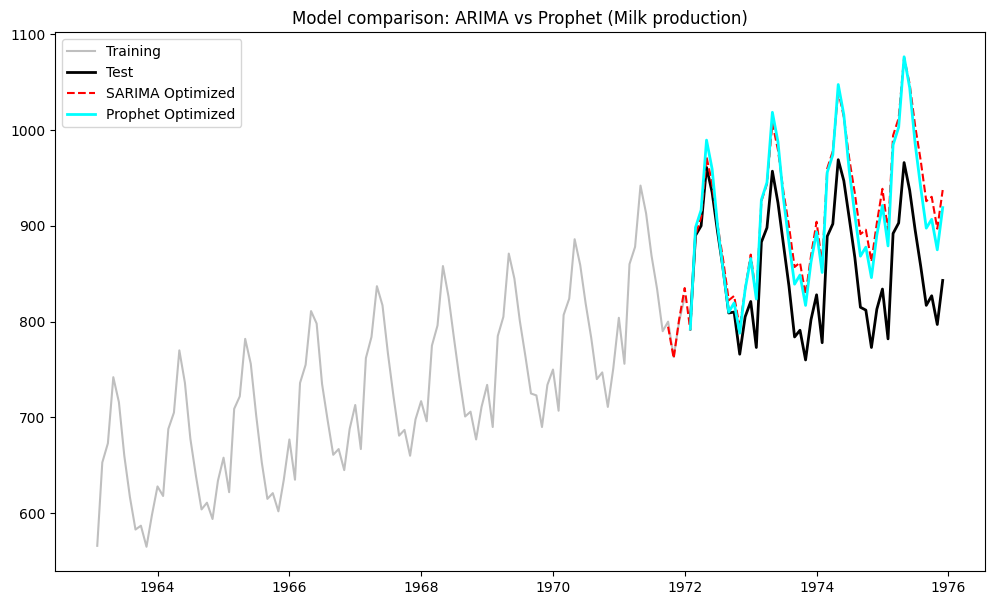

In [49]:
print(f"Best parameters: {best_params}")

# Prediction with the Optimized Prophet
future_opt = m_optimized.make_future_dataframe(periods=len(test), freq='MS')
forecast_opt = m_optimized.predict(future_opt)
prophet_values = forecast_opt['yhat'].iloc[-len(test):].values

plt.figure(figsize=(12, 7))
plt.plot(train.index, train['Milk_production'], label='Training', color='gray', alpha=0.5)
plt.plot(test.index, test['Milk_production'], label='Test', color='black', linewidth=2)

# Comparative graph
test_ajustado = test_data.iloc[-len(pred_mean):]
plt.plot(test_ajustado.index, pred_mean, label='SARIMA Optimized', color='red', linestyle='--')
plt.plot(test.index, prophet_values, label='Prophet Optimized', color='cyan', linewidth=2)

plt.title('Model comparison: ARIMA vs Prophet (Milk production)')
plt.legend()
plt.show()

In [50]:
def calcular_metricas(real, pred, nombre):
    mae = mean_absolute_error(real, pred)
    rmse = mean_squared_error(real, pred)**0.5
    print(f"--- {nombre} ---")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}\n")
    return mae, rmse


mae_a, rmse_a = calcular_metricas(test_ajustado['Milk_production'], pred_mean, "SARIMA")
mae_p, rmse_p = calcular_metricas(test['Milk_production'], prophet_values, "Prophet")


--- SARIMA ---
MAE: 59.54
RMSE: 69.96

--- Prophet ---
MAE: 56.54
RMSE: 63.47



Initially, it was observed that the Prophet model overestimates the linear growth of the dataset. While we could adjust changepoint_prior_scale to make it less sensitive to aggressive trends, the value found when searching for the optimal model parameters is already relatively low (0.001). Therefore, to improve the model's prediction, it was decided to change the seasonality mode from additive to multiplicative; this means that the magnitude of seasonal variations increases or decreases proportionally as the underlying trend grows or declines.

With this change, both models showed similar behavior; however, they continue to replicate the trend of the test set, which is not fully reproduced in that set.

# Step 5 - LSTM neural network model

Long Short-Term Memory (LSTM) is a specialized Recurrent Neural Network (RNN) architecture designed to learn long-term dependencies in sequential data, overcoming the vanishing gradient problem of traditional RNNs. LSTMs use memory cells and a gating mechanism (forget, input, output gates) to selectively retain or discard information, making them highly effective for time-series forecasting, natural language processing, and speech recognition.

In [40]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Dropout

In [ ]:
# Data scaling
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train['Milk_production'].values.reshape(-1, 1))
test_scaled = scaler.transform(test['Milk_production'].values.reshape(-1, 1))

# Function to create sequences (Time Windows)
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

In [ ]:
def optimize_lstm(train_data, param_grid):
    best_rmse = float('inf')
    best_params = {}
    
    for n_neurons in param_grid['neurons']:
        for length in param_grid['seq_length']:
            for epochs in param_grid['epochs']:
                # Re-prepare sequences for each length
                X, y = create_sequences(train_scaled, length)
                
                input_shape = (length, 1)

                model = Sequential([
                    Input(shape=input_shape),
                    LSTM(n_neurons, activation='relu'),
                    Dropout(0.2),
                    Dense(1)
                ])
                model.compile(optimizer='adam', loss='mse')
                model.fit(X, y, epochs=epochs, verbose=0)
                
                # Quick assessment in the final stage of training
                val_loss = model.evaluate(X[-10:], y[-10:], verbose=0)
                if val_loss < best_rmse:
                    best_rmse = val_loss
                    best_params = {'neurons': n_neurons, 'seq_length': length, 'epochs': epochs}
    return best_params

params = {
    'neurons': [50, 100],
    'seq_length': [12, 24],
    'epochs': [50, 100]
}
best_cfg = optimize_lstm(train_scaled, params)
print(f"Mejores Parámetros LSTM: {best_cfg}")


Mejores Parámetros LSTM: {'neurons': 100, 'seq_length': 24, 'epochs': 100}


In [ ]:
n_neurons_opt = best_cfg['neurons']
epochs_opt = best_cfg['epochs']
seq_length_opt = best_cfg['seq_length']

X_train, y_train = create_sequences(train_scaled, seq_length_opt)

# LSTM Base Model
input_shape = (seq_length_opt, 1)

model_lstm = Sequential([
    Input(shape=input_shape),
    LSTM(n_neurons_opt, activation='relu'),
    Dropout(0.2),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_train, y_train, epochs=epochs_opt, verbose=0)

In [ ]:
# 1. Take the latest training data to start the prediction
last_train_batch = train_scaled[-seq_length_opt:].reshape((1, seq_length_opt, 1))

lstm_predictions_scaled = []

# 2. Predict step by step over the horizon of the test set
current_batch = last_train_batch
for i in range(len(test_scaled)):
    # Get the prediction for the next month
    current_pred = model_lstm.predict(current_batch, verbose=0)[0]
    
    # Save the prediction
    lstm_predictions_scaled.append(current_pred)
    
    # Update the batch: remove the first value and add the prediction to the end
    current_batch = np.append(current_batch[:,1:,:], [[current_pred]], axis=1)

# 3. De-escalate the results
lstm_predictions = scaler.inverse_transform(lstm_predictions_scaled)


In [ ]:
# We ensure that all predictions have the same length as the test set
y_true = test_data['Milk_production'].values[-len(lstm_predictions):]
arima_final = pred_mean[-len(lstm_predictions):]
prophet_final = prophet_values[-len(lstm_predictions):]

def obtener_metrics(true, pred, name):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    return {'Modelo': name, 'MAE': mae, 'RMSE': rmse}

metrics_list = [
    obtener_metrics(y_true, arima_final, "SARIMA"),
    obtener_metrics(y_true, prophet_final, "Prophet"),
    obtener_metrics(y_true, lstm_predictions, "LSTM")
]

df_metrics = pd.DataFrame(metrics_list)
print(df_metrics)

    Modelo         MAE        RMSE
0   SARIMA   64.234899   72.859512
1  Prophet   56.538757   63.467054
2     LSTM  102.451561  124.341006


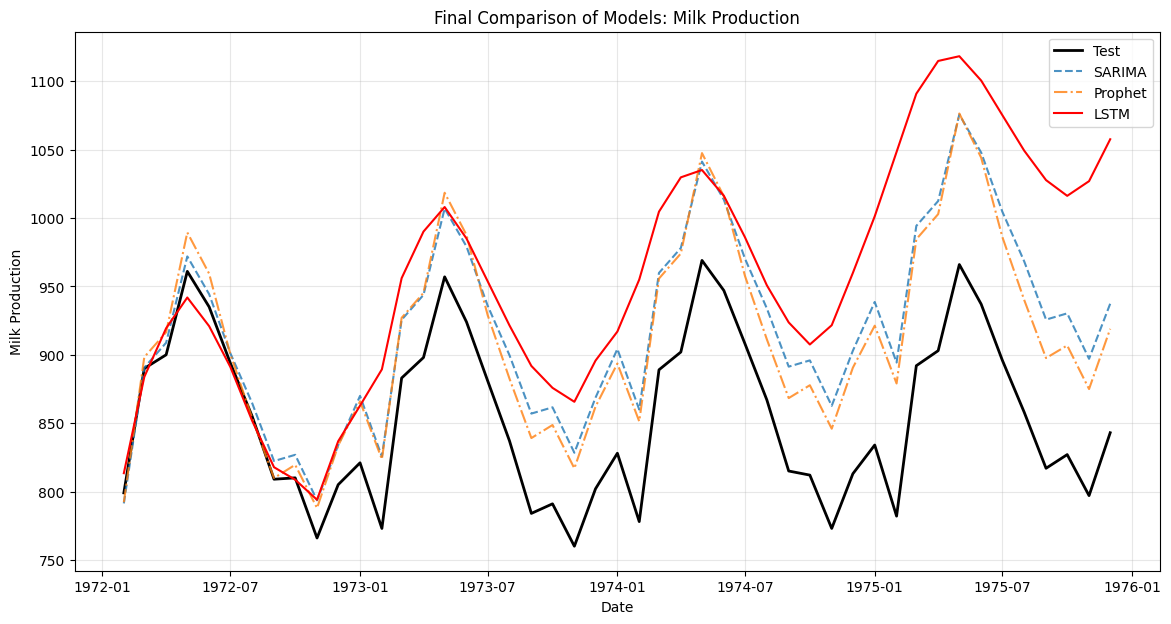

In [53]:
plt.figure(figsize=(14, 7))

# Real test data
index_test = test_data.index[-len(y_true):]
plt.plot(index_test, y_true, label='Test', color='black', linewidth=2)

# Model lines
plt.plot(index_test, arima_final, label='SARIMA', linestyle='--', alpha=0.8)
plt.plot(index_test, prophet_final, label='Prophet', linestyle='-.', alpha=0.8)
plt.plot(index_test, lstm_predictions, label='LSTM', color='red', linewidth=1.5)

plt.title('Final Comparison of Models: Milk Production')
plt.xlabel('Date')
plt.ylabel('Milk Production')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Although the LSTM model adequately captures the shape of the waves (seasonality), it detaches violently from reality upwards. In this case, we can observe that the LSTM model learned very well that between 1962 and 1971 production always increased. However, as we have observed in the other models, upon reaching the test period (1972-1976), the neural network "assumes" that this acceleration is infinite. Unlike SARIMA or Prophet, which have linear mathematical constraints, LSTM is a universal approximator and can generate exponential curves if it believes that to be the trend.

# Conclusions
- The models used are based on the premise that the future will behave like the past. In this sense, if the trend was consistently upward during the training period, the models have no mathematical reason to believe that production will stagnate. For the modeling purposes, stagnation is an external anomaly (changes in cow feed, economic crisis, extreme weather conditions, etc.) that is not present in the historical data.
- While models may be well-trained and produce adequate results with the training dataset, the reality of the data can change over time; for example, if the environmental conditions in the test set change. In practice, this indicates that the model needs to be recalibrated periodically with more recent data.
- Considering the results obtained for each model, the most suitable in this case would be the SARIMA model, as it is capable of achieving quite satisfactory results with a lower computational cost. This does not imply that the Prophet model is undervalued in terms of its predictive capacity; however, its higher computational cost could cause problems when making predictions with larger datasets.

# References

GitHub Repository ([Go](https://github.com/Jero2110/Advanced-ML_Phase-04.git))

In [55]:
!pip install bibtexparser

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 1.3 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for bibtexparser: filename=bibtexparser-1.4.4-py3-none-any.whl size=43609 sha256=053e47db195dbf999e75b3268c1282eaff5514597d67c4dccd7064153db0b6c2
  Stored in directory: /root/.cache/pip/wheels/54/f8/e6/ecfceb6af875ddc5096bb3811795ac336f50371009a601454d
Successfully built bibtexparser


In [56]:
import bibtexparser

with open("references.bib", "r", encoding="utf-8") as bib_file:
    bib_database = bibtexparser.load(bib_file)

for i, entry in enumerate(bib_database.entries, 1):
    url = entry.get("url", "unknown")
    authors    = entry.get("author", "Unknown Author")
    title      = entry.get("title", "No Title")
    year       = entry.get("year", "n.d.")
    journal    = entry.get("journal", entry.get("booktitle", ""))
    
    print(f"[{i}] {authors} ({year}). \033[3m{title}\033[0m. {journal} [{url}]")
    print()

[1] Zaina Saadeddin (2024). ARIMA para la previsión de series temporales: Guía completa. DataCamp [https://www.datacamp.com/es/tutorial/arima]

[2] Joshua Noble (n.d.). ¿Qué son los modelos ARIMA?. IBM [https://www.ibm.com/es-es/think/topics/arima-model]

[3] GeeksforGeeks Developers (n.d.). Autocorrelation and Partial Autocorrelation. GeeksforGeeks [https://www.geeksforgeeks.org/r-machine-learning/autocorrelation-and-partial-autocorrelation/]

[4] GeeksforGeeks (n.d.). What is Lag in Time Series Forecasting. GeeksforGeeks [https://www.geeksforgeeks.org/machine-learning/what-is-lag-in-time-series-forecasting/]

[5] Further Maths (2011). Maths Tutorial: Patterns and Trends in Time Series Plots (statistics). YouTube [https://www.youtube.com/watch?v=ca0rDWo7IpI]

[6] GeeksforGeeks (n.d.). Understanding Partial Autocorrelation Functions (PACF) in Time Series Data - GeeksforGeeks. GeeksforGeeks [https://www.geeksforgeeks.org/machine-learning/understanding-partial-autocorrelation-functions-p